# Chapter 6

## Data cleaning, Imbalanced Data, and Other Data Problems

This notebook is a companion to the book _XGBoost for Regression Predictive Modeling and Time Series Analysis_.
This chapter covers how to address common problems with real-life data sets and this code is a series of Python data cleaning functions.


In [1]:
# ----------------------------------------
# filename datacleaning.ipynb
# Python functions to perform common data cleaning tasks
# author Joyce Weiner
# revision 1.0
# revision history 1.0 - initial script
# ----------------------------------------

# These functions all use pandas
import pandas as pd
import numpy as np

In [2]:
# Create a test dataframe to use to verify the functions work correctly
testdf = pd.DataFrame(np.random.randn(5250, 3), columns=list("ABC"))
testdf["category"] = "Category A"
testdf.loc[3000:4499, ["category"]] = "CategoryB"  # Use .loc for slice assignment
testdf.loc[4500:5250, ["category"]] = "Cat C"  # Use .loc for slice assignment
testdf.insert(
    len(testdf.columns),
    "Date",
    np.random.choice(pd.date_range("2022-10-01", "2024-11-30"), len(testdf)),
)

In [3]:
testdf

,A,B,C,category,Date
0,1.697084,0.242910,2.223127,Category A,2024-07-21
1,0.845398,-0.881545,0.329080,Category A,2024-02-17
2,-0.590146,0.183106,1.783186,Category A,2022-11-13
3,-0.283646,-2.284945,0.306516,Category A,2023-08-24
4,-0.212469,-1.051556,-2.013009,Category A,2024-04-21
...,...,...,...,...,...
5245,-0.175009,-0.570199,-0.760066,Cat C,2024-10-03
5246,1.099181,0.144285,-0.219850,Cat C,2024-04-07
5247,1.474737,0.671390,-1.172856,Cat C,2024-09-03
5248,1.233943,0.594368,1.940827,Cat C,2023-07-29


## Example of multimodal data using the Iris dataset


In [4]:
import seaborn as sns

# load the iris data set from scikit-learn
from sklearn import datasets

irisarray = datasets.load_iris()
# bring the array into a pandas dataframe and label the headers
irisdata = pd.DataFrame(data=irisarray.data, columns=irisarray.feature_names)
irisdata["Species"] = irisarray.target

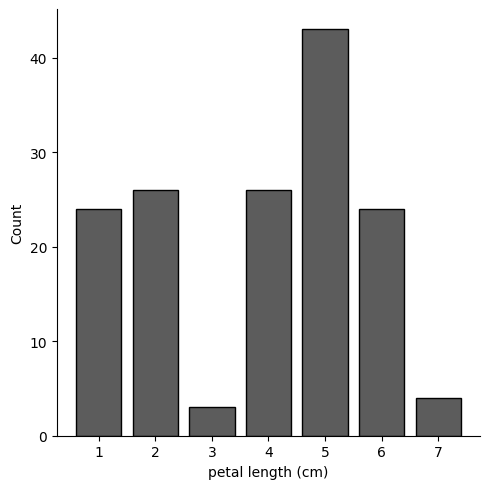

In [5]:
sns.set_palette("dark:grey")
sns.displot(irisdata, x="petal length (cm)", discrete=True, shrink=0.8)

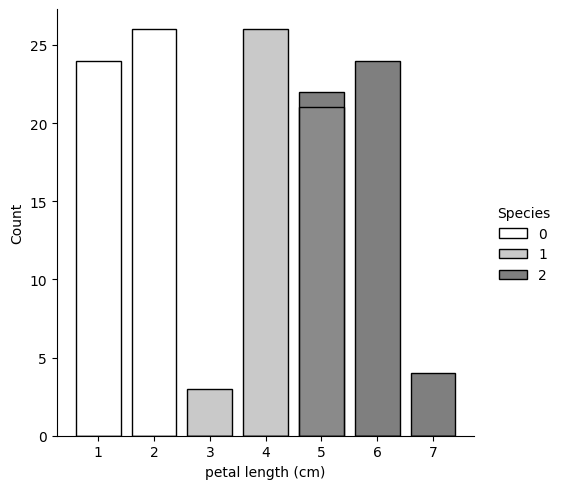

In [6]:
sns.displot(
    irisdata,
    x="petal length (cm)",
    discrete=True,
    hue="Species",
    shrink=0.8,
    palette="Greys",
)

### 4-pseudo sigma filter for continuous data


In [7]:
def pseudosigmafilter(df, col, sigma=4):
    """Filters data using a sigma-based threshold."""
    mean = df[col].mean()
    std = df[col].std()

    # Use .between() for a much cleaner boolean mask
    mask = df[col].between(mean - sigma * std, mean + sigma * std)

    # Assign new column: keep value where mask is True, else NaN
    df[f"filter_{col}"] = df[col].where(mask)

    return df

In [8]:
# Inject a huge value in Category A and test that it is filtered
testdf.at[0, "A"] = 11

pseudosigmafilter(testdf, "A")

,A,B,C,category,Date,filter_A
0,11.000000,0.242910,2.223127,Category A,2024-07-21,NaN
1,0.845398,-0.881545,0.329080,Category A,2024-02-17,0.845398
2,-0.590146,0.183106,1.783186,Category A,2022-11-13,-0.590146
3,-0.283646,-2.284945,0.306516,Category A,2023-08-24,-0.283646
4,-0.212469,-1.051556,-2.013009,Category A,2024-04-21,-0.212469
...,...,...,...,...,...,...
5245,-0.175009,-0.570199,-0.760066,Cat C,2024-10-03,-0.175009
5246,1.099181,0.144285,-0.219850,Cat C,2024-04-07,1.099181
5247,1.474737,0.671390,-1.172856,Cat C,2024-09-03,1.474737
5248,1.233943,0.594368,1.940827,Cat C,2023-07-29,1.233943


### Standardizing continuous data


In [9]:
from sklearn import preprocessing

continuous = testdf[["A", "B", "C"]]
continuous.head()

,A,B,C
0,11.000000,0.242910,2.223127
1,0.845398,-0.881545,0.329080
2,-0.590146,0.183106,1.783186
3,-0.283646,-2.284945,0.306516
4,-0.212469,-1.051556,-2.013009


In [10]:
standardized = preprocessing.StandardScaler().fit(continuous)

In [11]:
standardized = standardized.transform(continuous)
standardized

array([[10.79538097,  0.26605894,  2.22447395],
       [ 0.83351562, -0.87276071,  0.32669158],
       [-0.57478137,  0.20549176,  1.78366463],
       ...,
       [ 1.45090955,  0.70001305, -1.17820578],
       [ 1.21468589,  0.62200697,  1.94161643],
       [ 0.77546847,  1.4178973 ,  1.23044575]], shape=(5250, 3))

In [12]:
standardizeddf = pd.DataFrame(standardized, columns=["A", "B", "C"])
standardizeddf.head()

,A,B,C
0,10.795381,0.266059,2.224474
1,0.833516,-0.872761,0.326692
2,-0.574781,0.205492,1.783665
3,-0.274099,-2.294090,0.304083
4,-0.204273,-1.044944,-2.020016


In [13]:
standardizedtestdf = pd.concat([testdf, standardizeddf], axis=1)
standardizedtestdf.head()

,A,B,C,category,Date,filter_A,A,B,C
0,11.000000,0.242910,2.223127,Category A,2024-07-21,NaN,10.795381,0.266059,2.224474
1,0.845398,-0.881545,0.329080,Category A,2024-02-17,0.845398,0.833516,-0.872761,0.326692
2,-0.590146,0.183106,1.783186,Category A,2022-11-13,-0.590146,-0.574781,0.205492,1.783665
3,-0.283646,-2.284945,0.306516,Category A,2023-08-24,-0.283646,-0.274099,-2.294090,0.304083
4,-0.212469,-1.051556,-2.013009,Category A,2024-04-21,-0.212469,-0.204273,-1.044944,-2.020016


#### Centering data


In [14]:
centered = preprocessing.StandardScaler(with_std=False).fit(continuous)
centered.transform(continuous)

array([[11.00424363,  0.2627028 ,  2.22009596],
       [ 0.84964199, -0.86175148,  0.32604862],
       [-0.5859019 ,  0.20289963,  1.7801542 ],
       ...,
       [ 1.47898089,  0.69118291, -1.17588695],
       [ 1.23818692,  0.61416081,  1.93779514],
       [ 0.79047178,  1.40001158,  1.22802411]], shape=(5250, 3))

### Normalizing continuous data


In [15]:
from sklearn import preprocessing


def normalizecolumn(dataframe, parameter):
    colarray = np.array(dataframe[parameter])
    normalizedarray = preprocessing.normalize([colarray]).tolist()
    normalizedarray = np.swapaxes(normalizedarray, 0, 1)
    dataframe["normalized_" + parameter] = normalizedarray
    return dataframe

In [16]:
normalizecolumn(testdf, "B")

,A,B,C,category,Date,filter_A,normalized_B
0,11.000000,0.242910,2.223127,Category A,2024-07-21,NaN,0.003395
1,0.845398,-0.881545,0.329080,Category A,2024-02-17,0.845398,-0.012319
2,-0.590146,0.183106,1.783186,Category A,2022-11-13,-0.590146,0.002559
3,-0.283646,-2.284945,0.306516,Category A,2023-08-24,-0.283646,-0.031932
4,-0.212469,-1.051556,-2.013009,Category A,2024-04-21,-0.212469,-0.014695
...,...,...,...,...,...,...,...
5245,-0.175009,-0.570199,-0.760066,Cat C,2024-10-03,-0.175009,-0.007968
5246,1.099181,0.144285,-0.219850,Cat C,2024-04-07,1.099181,0.002016
5247,1.474737,0.671390,-1.172856,Cat C,2024-09-03,1.474737,0.009383
5248,1.233943,0.594368,1.940827,Cat C,2023-07-29,1.233943,0.008306


### Correcting spelling in a column


In [17]:
def cleancategory(df, parameter):
    if parameter == "category":
        df[f"clean_{parameter}"] = "Category " + df[parameter].astype(str).str[-1]
    return df

In [18]:
cleancategory(testdf, "category")

,A,B,C,category,Date,filter_A,normalized_B,clean_category
0,11.000000,0.242910,2.223127,Category A,2024-07-21,NaN,0.003395,Category A
1,0.845398,-0.881545,0.329080,Category A,2024-02-17,0.845398,-0.012319,Category A
2,-0.590146,0.183106,1.783186,Category A,2022-11-13,-0.590146,0.002559,Category A
3,-0.283646,-2.284945,0.306516,Category A,2023-08-24,-0.283646,-0.031932,Category A
4,-0.212469,-1.051556,-2.013009,Category A,2024-04-21,-0.212469,-0.014695,Category A
...,...,...,...,...,...,...,...,...
5245,-0.175009,-0.570199,-0.760066,Cat C,2024-10-03,-0.175009,-0.007968,Category C
5246,1.099181,0.144285,-0.219850,Cat C,2024-04-07,1.099181,0.002016,Category C
5247,1.474737,0.671390,-1.172856,Cat C,2024-09-03,1.474737,0.009383,Category C
5248,1.233943,0.594368,1.940827,Cat C,2023-07-29,1.233943,0.008306,Category C


### Reformatting date data


In [19]:
testdf["Date_new"] = testdf["Date"].dt.strftime("%d-%b-%Y")
testdf.head()

,A,B,C,category,Date,filter_A,normalized_B,clean_category,Date_new
0,11.000000,0.242910,2.223127,Category A,2024-07-21,NaN,0.003395,Category A,21-Jul-2024
1,0.845398,-0.881545,0.329080,Category A,2024-02-17,0.845398,-0.012319,Category A,17-Feb-2024
2,-0.590146,0.183106,1.783186,Category A,2022-11-13,-0.590146,0.002559,Category A,13-Nov-2022
3,-0.283646,-2.284945,0.306516,Category A,2023-08-24,-0.283646,-0.031932,Category A,24-Aug-2023
4,-0.212469,-1.051556,-2.013009,Category A,2024-04-21,-0.212469,-0.014695,Category A,21-Apr-2024


In [20]:
testdf["Date_US"] = testdf["Date"].dt.strftime("%m/%d/%Y")
testdf.head()

,A,B,C,category,Date,filter_A,normalized_B,clean_category,Date_new,Date_US
0,11.000000,0.242910,2.223127,Category A,2024-07-21,NaN,0.003395,Category A,21-Jul-2024,07/21/2024
1,0.845398,-0.881545,0.329080,Category A,2024-02-17,0.845398,-0.012319,Category A,17-Feb-2024,02/17/2024
2,-0.590146,0.183106,1.783186,Category A,2022-11-13,-0.590146,0.002559,Category A,13-Nov-2022,11/13/2022
3,-0.283646,-2.284945,0.306516,Category A,2023-08-24,-0.283646,-0.031932,Category A,24-Aug-2023,08/24/2023
4,-0.212469,-1.051556,-2.013009,Category A,2024-04-21,-0.212469,-0.014695,Category A,21-Apr-2024,04/21/2024


### Sampling data for each class to match the class with the smallest number of observations


In [21]:
# Use pandas to select a random sample by category
# dataframe = pandas dataframe to modify
# category = name of column in dataframe
# nsamples = number of rows


def subsamplecategory(olddataframe, category, nsamples):
    newdataframe = olddataframe.groupby(category).apply(lambda s: s.sample(nsamples))
    return newdataframe

In [22]:
newdf = subsamplecategory(testdf, "category", 750)
newdf

A         B         C       Date  filter_A  \
category                                                            
Cat C     5126 -1.867477  1.291025  0.985202 2023-05-11 -1.867477   
          4685 -0.333488 -1.023022 -1.702613 2023-03-01 -0.333488   
          5086  0.730616 -0.282562  0.178233 2024-02-14  0.730616   
          5098  0.446449  1.169600  0.822724 2023-12-15  0.446449   
          4543 -0.296075 -0.619631 -0.160098 2023-09-02 -0.296075   
...                  ...       ...       ...        ...       ...   
CategoryB 4307 -0.316679  1.280797 -0.982696 2024-11-25 -0.316679   
          4416 -0.953246  0.021915  2.134101 2023-05-22 -0.953246   
          4111  0.607443  2.182237  0.157885 2023-05-31  0.607443   
          3730 -0.477984  0.044440  0.691684 2023-08-21 -0.477984   
          3691  1.413416  0.052524  0.253965 2023-07-12  1.413416   

                normalized_B clean_category     Date_new     Date_US  
category                                                              
Cat C     5126      0.018042     Category C  11-May-2023  05/11/2023  
          4685     -0.014297     Category C  01-Mar-2023  03/01/2023  
          5086     -0.003949     Category C  14-Feb-2024  02/14/2024  
          5098      0.016345     Category C  15-Dec-2023  12/15/2023  
          4543     -0.008659     Category C  02-Sep-2023  09/02/2023  
...                      ...            ...          ...         ...  
CategoryB 4307      0.017899     Category B  25-Nov-2024  11/25/2024  
          4416      0.000306     Category B  22-May-2023  05/22/2023  
          4111      0.030496     Category B  31-May-2023  05/31/2023  
          3730      0.000621     Category B  21-Aug-2023  08/21/2023  
          3691      0.000734     Category B  12-Jul-2023  07/12/2023  

[2250 rows x 9 columns]